<center><h1><span style="color: green;">THỰC HÀNH BUỔI 13.1</span></h1></center>

# Ví dụ 1

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Tạo dữ liệu
np.random.seed(21)
means = [[2, 2], [4, 1]]
cov = [[.3, .2], [.2, .3]]
N = 10  # số mẫu mỗi lớp

X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)

# Chèn nhiễu
X0[-1, :] = [4.5, 1.2]
X1[-1, :] = [2.7, 2]

X = np.concatenate((X0.T, X1.T), axis=1)  # shape: (2, 2N)
y = np.concatenate((np.ones((1, N)), -1*np.ones((1, N))), axis=1)  # shape: (1, 2N)


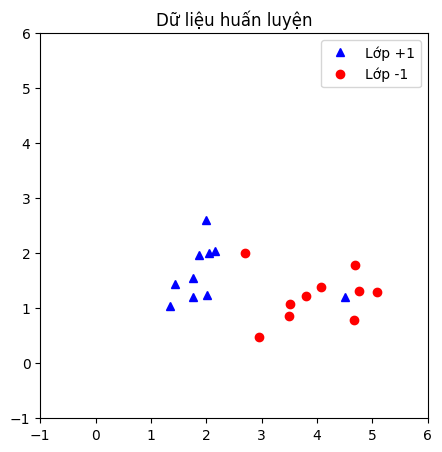

In [30]:

# Vẽ dữ liệu
plt.figure(figsize=(5, 5))
plt.plot(X0[:, 0], X0[:, 1], 'b^', label='Lớp +1')
plt.plot(X1[:, 0], X1[:, 1], 'ro', label='Lớp -1')
plt.legend()
plt.title('Dữ liệu huấn luyện')
plt.axis([-1, 6, -1, 6])
plt.show()


## CÁCH 1: Dùng phương pháp đối ngẫu với Lagrange (CVXOPT)

In [31]:
from cvxopt import matrix, solvers

C = 100
V = np.concatenate((X0.T, -X1.T), axis=1)
K = matrix(V.T @ V)
q = matrix(-np.ones((2*N, 1)))
G = matrix(np.vstack((-np.eye(2*N), np.eye(2*N))))
h = matrix(np.vstack((np.zeros((2*N, 1)), C * np.ones((2*N, 1)))))
A = matrix(y.reshape((-1, 2*N)))
b = matrix(np.zeros((1, 1)))

solvers.options['show_progress'] = False
sol = solvers.qp(K, q, G, h, A, b)
l = np.array(sol['x'])

# Lấy chỉ số của support vectors
S = np.where(l > 1e-5)[0]
S2 = np.where(l < .999*C)[0]
M = [val for val in S if val in S2]

# Tính w và b
XT = X  
VS = V[:, S]
lS = l[S]
XM = XT[:, M]  
yM = y[:, M]   

w_dual = VS @ lS
b_dual = np.mean(yM.T - w_dual.T @ XM)

print("Cách 1 - w:", w_dual.T)
print("Cách 1 - b:", b_dual)


Cách 1 - w: [[-1.06640598  1.01378208]]
Cách 1 - b: 1.6623905770024907


## CÁCH 2: Dùng Gradient Descent để tối ưu hàm hinge loss

In [32]:
# Chuẩn bị dữ liệu mở rộng
X0_bar = np.vstack((X0.T, np.ones((1, N))))
X1_bar = np.vstack((X1.T, np.ones((1, N))))
Z = np.hstack((X0_bar, -X1_bar))
lam = 1. / C

def cost(w):
    u = w.T @ Z
    return (np.sum(np.maximum(0, 1 - u)) + 0.5 * lam * np.sum(w*w)) - 0.5 * lam * w[-1]**2

def grad(w):
    u = w.T @ Z
    H = np.where(u < 1)[1]
    ZS = Z[:, H]
    g = -np.sum(ZS, axis=1, keepdims=True) + lam * w
    g[-1] -= lam * w[-1]
    return g

def grad_descent(w0, eta=0.001, tol=1e-5, max_iter=100000):
    w = w0.copy()
    for it in range(max_iter):
        g = grad(w)
        w -= eta * g
        if np.linalg.norm(g) < tol:
            break
    return w

w0 = np.random.randn(X0_bar.shape[0], 1)
w_gd = grad_descent(w0)
w_hinge = w_gd[:-1]
b_hinge = w_gd[-1]

print("Cách 2 - w:", w_hinge.T)
print("Cách 2 - b:", b_hinge)


Cách 2 - w: [[-1.07049082  0.99874462]]
Cách 2 - b: [1.68169917]


## CÁCH 3: Dùng thư viện sklearn.svm.SVC

In [33]:
from sklearn.svm import SVC

y1 = y.reshape((2*N,))
X1 = X.T  # mỗi mẫu là một hàng
clf = SVC(kernel='linear', C=100)
clf.fit(X1, y1)

w_lib = clf.coef_.T
b_lib = clf.intercept_

print("Cách 3 - w:", w_lib.T)
print("Cách 3 - b:", b_lib)


Cách 3 - w: [[-1.06600888  1.01354038]]
Cách 3 - b: [1.66151836]


# Bài tập thực hành 1:

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
from cvxopt import matrix, solvers
from sklearn.svm import SVC

# Tạo dữ liệu
np.random.seed(21)
means = [[2, 2], [4, 1]]
cov = [[.3, .2], [.2, .3]]
N = 10
X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X0[-1, :] = [4.5, 1.2]
X1[-1, :] = [2.7, 2]
X = np.concatenate((X0.T, X1.T), axis=1)
y = np.concatenate((np.ones((1, N)), -1*np.ones((1, N))), axis=1)

# Chuẩn bị cho cách 2
X0_bar = np.vstack((X0.T, np.ones((1, N))))
X1_bar = np.vstack((X1.T, np.ones((1, N))))
Z_base = np.hstack((X0_bar, -X1_bar))

def predict_linear(w, b, X):
    return np.sign(w.T @ X + b).flatten()

def evaluate_and_plot(w, b, X, y_true, method_name=""):
    y_pred = np.sign(w.T @ X + b).flatten()
    acc = accuracy_score(y_true.flatten(), y_pred)
    cm = confusion_matrix(y_true.flatten(), y_pred)

    print(f"\n {method_name}")
    print(f"Accuracy: {acc * 100:.2f}%")

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Class -1', 'Class +1'],
                yticklabels=['Class -1', 'Class +1'])
    plt.title(f'Confusion Matrix - {method_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

In [44]:
from cvxopt import matrix

#  Cách 1 – Lagrange Dual (CVXOPT)
def svm_dual_cvxopt(C, X, y):
    V = np.concatenate((X0.T, -X1.T), axis=1)
    K = matrix(V.T @ V)
    q = matrix(-np.ones((2*N, 1)))
    G = matrix(np.vstack((-np.eye(2*N), np.eye(2*N))))
    h = matrix(np.vstack((np.zeros((2*N, 1)), C * np.ones((2*N, 1)))))
    A = matrix(y.reshape((-1, 2*N)))
    b = matrix(np.zeros((1, 1)))

    solvers.options['show_progress'] = False
    sol = solvers.qp(K, q, G, h, A, b)
    l = np.array(sol['x'])

    S = np.where(l > 1e-5)[0]
    S2 = np.where(l < .999*C)[0]
    M = [val for val in S if val in S2]

    VS = V[:, S]
    lS = l[S]
    XM = X[:, M]
    yM = y[:, M]
    w = VS @ lS
    b = np.mean(yM.T - w.T @ XM)

    evaluate_and_plot(w, b, X, y, f"Cách 1 - Dual SVM (C={C})")


# Cách 2 – Gradient Descent
def svm_gradient_descent(C, X, y):
    lam = 1. / C
    Z = Z_base

    def cost(w):
        u = w.T @ Z
        return (np.sum(np.maximum(0, 1 - u)) + 0.5 * lam * np.sum(w*w)) - 0.5 * lam * w[-1]**2

    def grad(w):
        u = w.T @ Z
        H = np.where(u < 1)[1]
        ZS = Z[:, H]
        g = -np.sum(ZS, axis=1, keepdims=True) + lam * w
        g[-1] -= lam * w[-1]
        return g

    def grad_descent(w0, eta=0.001, tol=1e-5, max_iter=100000):
        w = w0.copy()
        for _ in range(max_iter):
            g = grad(w)
            w -= eta * g
            if np.linalg.norm(g) < tol:
                break
        return w

    w0 = np.random.randn(Z.shape[0], 1)
    w_all = grad_descent(w0)
    w, b = w_all[:-1], w_all[-1]
    evaluate_and_plot(w, b, X, y, f"Cách 2 - Gradient Descent (C={C})")

# Cách 3 – SVC từ thư viện sklearn
def svm_sklearn(C, X, y):
    clf = SVC(kernel='linear', C=C)
    clf.fit(X.T, y.flatten())
    w = clf.coef_.reshape(-1, 1)
    b = clf.intercept_[0]
    evaluate_and_plot(w, b, X, y, f"Cách 3 - Sklearn SVC (C={C})")


#### 1. Sử dụng bộ trọng số W đã tính được đưa ra độ chính xác Accuracy và ma trận nhầm lẫn Confusion Matrix theo mỗi phương pháp.



 Cách 1 - Dual SVM (C=100)
Accuracy: 90.00%


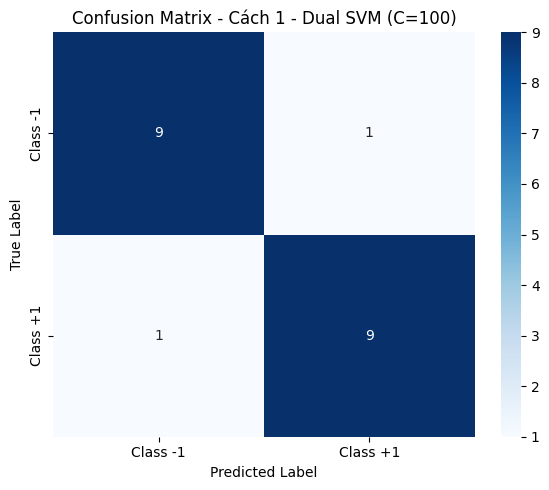


 Cách 2 - Gradient Descent (C=100)
Accuracy: 90.00%


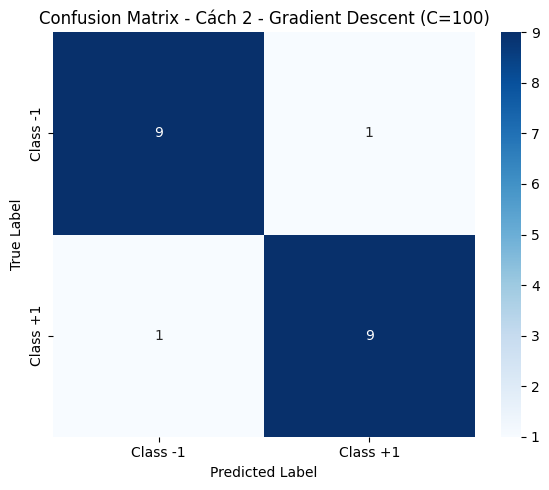


 Cách 3 - Sklearn SVC (C=100)
Accuracy: 90.00%


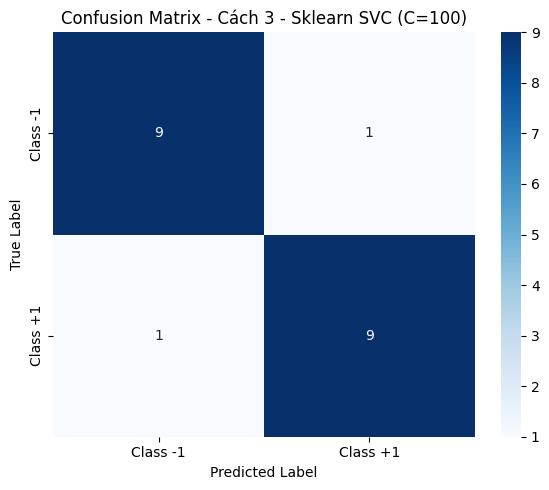

In [45]:
C_default = 100

# -- Cách 1 --
svm_dual_cvxopt(C_default, X, y)

# -- Cách 2 --
svm_gradient_descent(C_default, X, y)

# -- Cách 3 --
svm_sklearn(C_default, X, y)

#### 2. Lần lượt thay các giá trị của hằng số C là 1000; 200; 10; 0.5 và cho biết kết quả chạy các đoạnchương trình mẫu, gồm: bộ hệ số w, w0 ; độ chính các Accuracy và Confusion Matrix.


====================== C = 1000 ======================

 Cách 1 - Dual SVM (C=1000)
Accuracy: 90.00%


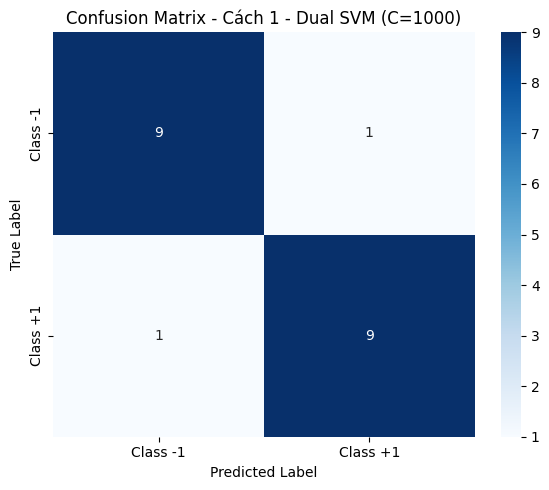


 Cách 2 - Gradient Descent (C=1000)
Accuracy: 90.00%


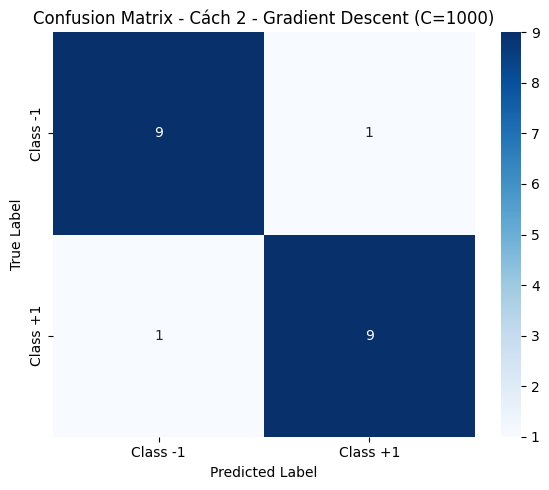


 Cách 3 - Sklearn SVC (C=1000)
Accuracy: 90.00%


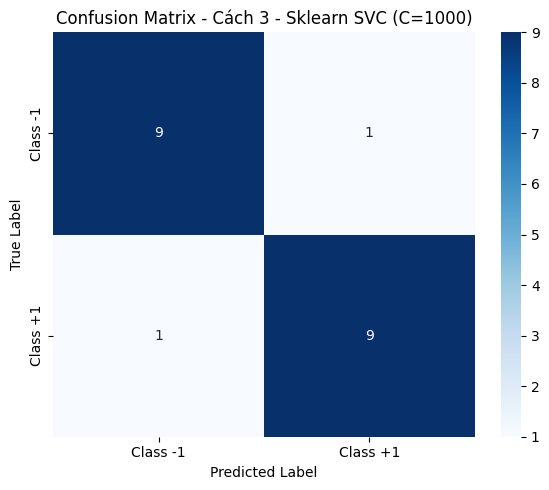


====================== C = 200 ======================

 Cách 1 - Dual SVM (C=200)
Accuracy: 90.00%


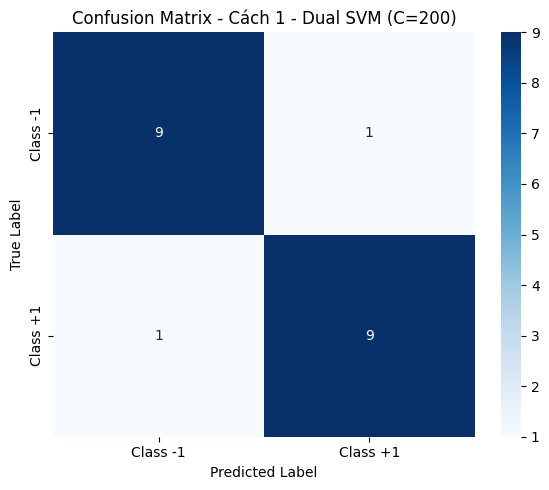


 Cách 2 - Gradient Descent (C=200)
Accuracy: 90.00%


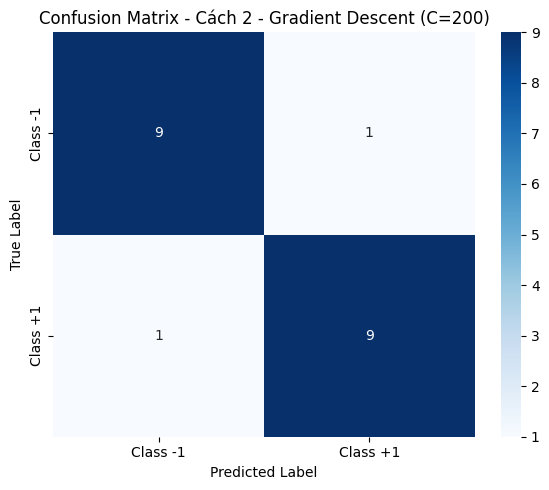


 Cách 3 - Sklearn SVC (C=200)
Accuracy: 90.00%


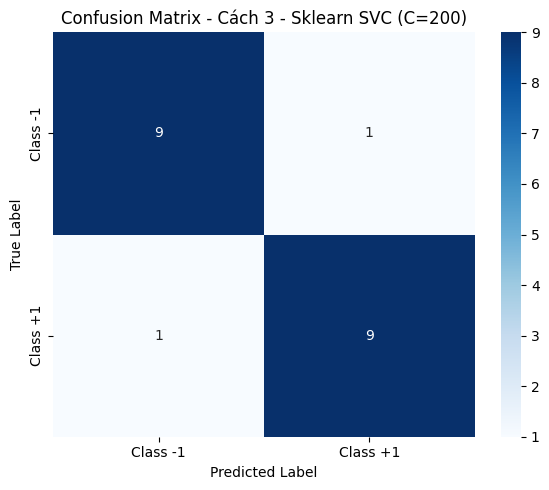


====================== C = 10 ======================

 Cách 1 - Dual SVM (C=10)
Accuracy: 90.00%


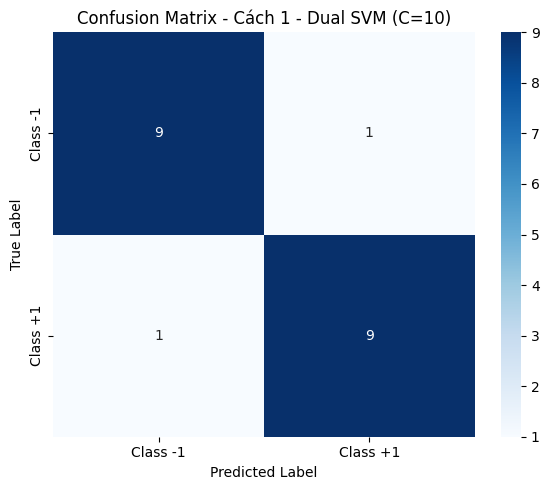


 Cách 2 - Gradient Descent (C=10)
Accuracy: 90.00%


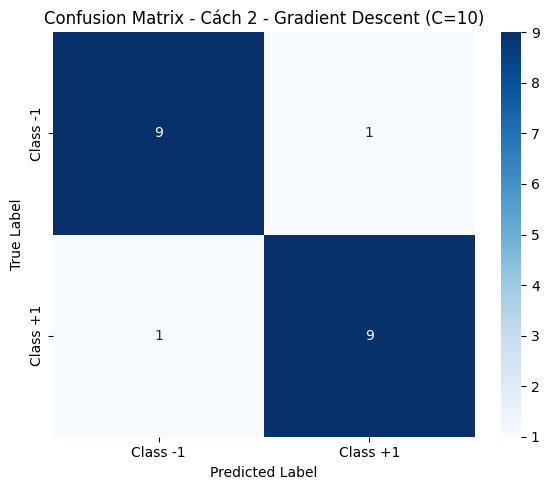


 Cách 3 - Sklearn SVC (C=10)
Accuracy: 90.00%


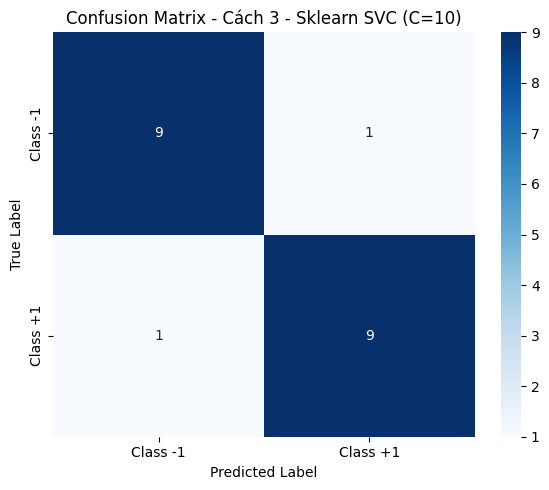


====================== C = 0.5 ======================

 Cách 1 - Dual SVM (C=0.5)
Accuracy: 90.00%


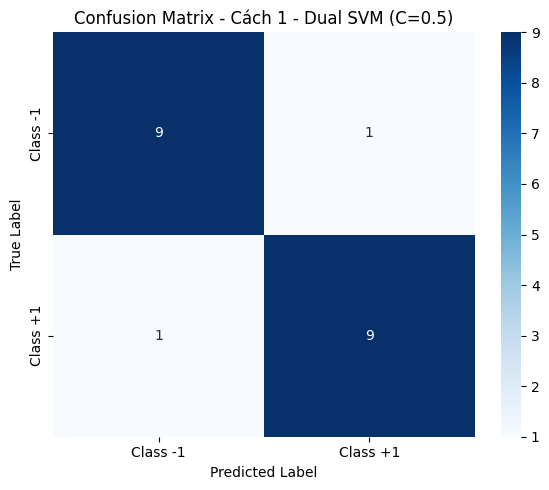


 Cách 2 - Gradient Descent (C=0.5)
Accuracy: 90.00%


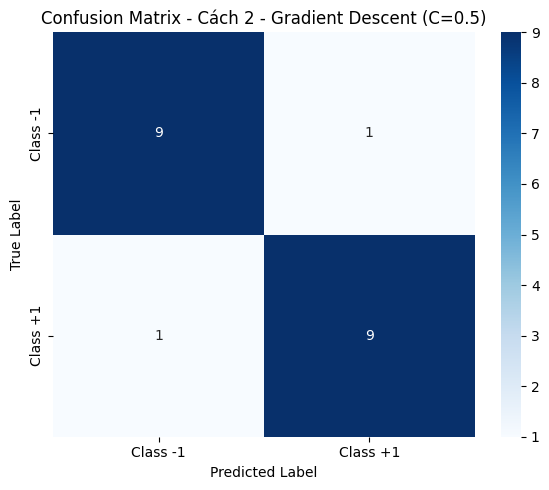


 Cách 3 - Sklearn SVC (C=0.5)
Accuracy: 90.00%


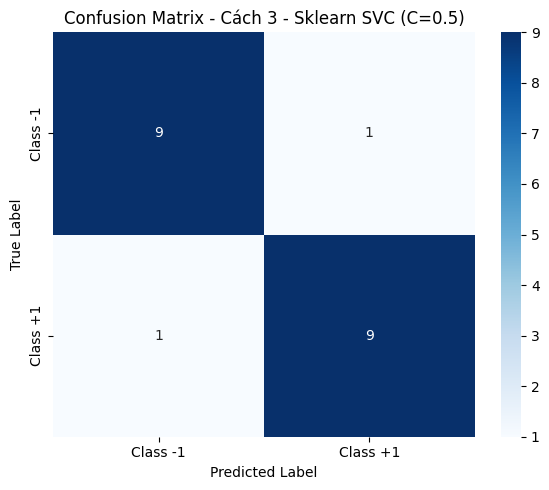

In [46]:
C_values = [1000, 200, 10, 0.5]

for C in C_values:
    print(f"\n====================== C = {C} ======================")
    svm_dual_cvxopt(C, X, y)
    svm_gradient_descent(C, X, y)
    svm_sklearn(C, X, y)

## Bài tập thực hành 2:

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# Đọc dữ liệu ung thư vú từ sklearn
cancer_data = datasets.load_breast_cancer()
X = cancer_data.data
y = cancer_data.target  # 0 = Malignant (ác tính), 1 = Benign (lành tính)

# Chia tập huấn luyện và kiểm tra (70% - 30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=109
)

Accuracy: 96.49%


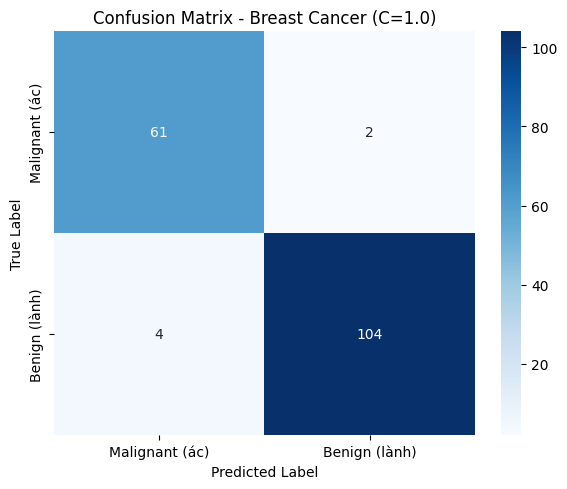

In [48]:
# Thiết lập giá trị C (có thể thử nhiều giá trị khác nhau: 0.1, 1, 10, 100)
C = 1.0

# Khởi tạo và huấn luyện mô hình SVM với kernel tuyến tính
clf = SVC(kernel='linear', C=C)
clf.fit(X_train, y_train)

# Dự đoán trên tập kiểm tra
y_pred = clf.predict(X_test)

# Đánh giá độ chính xác
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc * 100:.2f}%")

# Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)

# Trực quan hóa ma trận nhầm lẫn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Malignant (ác)', 'Benign (lành)'],
            yticklabels=['Malignant (ác)', 'Benign (lành)'])
plt.title(f'Confusion Matrix - Breast Cancer (C={C})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Ví dụ 2

### Phân loại Sonar: Rocks vs. Mines bằng Soft Margin SVM

#### 1. Đọc dữ liệu và xử lý nhãn

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu từ file CSV (không có header)
data = pd.read_csv("Sonar.all-data.csv", header=None)

# Tách dữ liệu và nhãn
X = data.iloc[:, :-1].values       # 60 cột đặc trưng
y_raw = data.iloc[:, -1].values    # nhãn: 'R' hoặc 'M'

# Chuyển đổi nhãn: R → -1, M → +1
y = np.array([1 if label == 'M' else -1 for label in y_raw])    

#### 2. Chia dữ liệu huấn luyện và kiểm tra

In [51]:
# Chia tập train/test theo tỉ lệ 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

#### 3. Huấn luyện mô hình SVM Soft Margin

In [52]:
# Thiết lập giá trị C cho Soft Margin (có thể điều chỉnh: 0.1, 1, 10,...)
C = 1.0

# Huấn luyện SVM với kernel tuyến tính
clf = SVC(kernel='linear', C=C)
clf.fit(X_train, y_train)

SVC(kernel='linear')

#### 4. Dự đoán và đánh giá mô hình

Accuracy: 79.37%


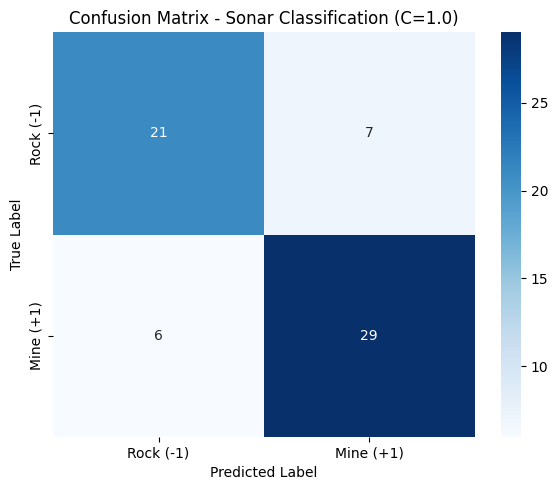

In [54]:
# Dự đoán trên tập kiểm tra
y_pred = clf.predict(X_test)

# Độ chính xác
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc * 100:.2f}%")

# Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)

# Trực quan hóa confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rock (-1)', 'Mine (+1)'],
            yticklabels=['Rock (-1)', 'Mine (+1)'])
plt.title(f'Confusion Matrix - Sonar Classification (C={C})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Ví dụ 3 

### Phân loại thư rác (Spam Detection)

#### 1. Đọc dữ liệu và xử lý nhãn

In [60]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Tải dữ liệu Spambase từ UCI
spambase = fetch_ucirepo(id=94)

# Lấy đặc trưng và nhãn
X = spambase.data.features          # dataframe
y_raw = spambase.data.targets       # dataframe, nhãn là 0 hoặc 1

# Chuyển nhãn về numpy array và ánh xạ thành {-1, +1}
y = y_raw.values.flatten()
y = np.where(y == 1, 1, -1)


#### 2. Tách tập huấn luyện và kiểm tra

In [61]:
# Chia tập train/test theo tỉ lệ 70/30
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.3, random_state=42
)

#### 3. Huấn luyện mô hình Soft Margin SVM

In [62]:
# Thiết lập giá trị C
C = 1.0

# Huấn luyện SVM với kernel tuyến tính
clf = SVC(kernel='linear', C=C)
clf.fit(X_train, y_train)

SVC(kernel='linear')

#### 4. Dự đoán và đánh giá

Accuracy: 92.61%


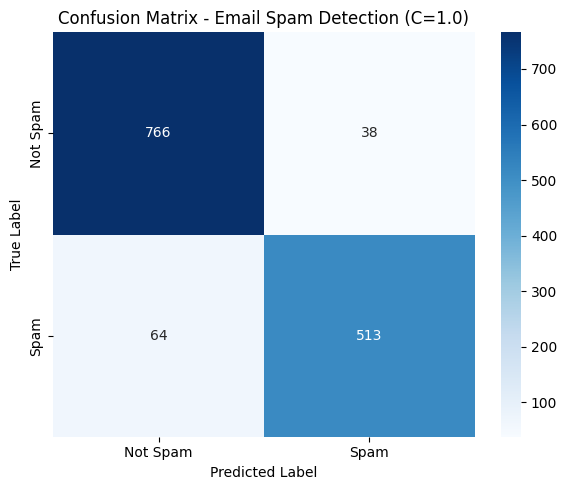

In [63]:
# Dự đoán trên tập kiểm tra
y_pred = clf.predict(X_test)

# Tính độ chính xác
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc * 100:.2f}%")

# Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)

# Vẽ ma trận nhầm lẫn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])
plt.title(f'Confusion Matrix - Email Spam Detection (C={C})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Ví dụ 5

### Dự đoán trúng tuyển cao học bằng SVM Soft Margin

#### 1. Đọc dữ liệu và xử lý nhãn

In [56]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Đọc dữ liệu từ file CSV
data = pd.read_csv("Admission_Predict.csv")

# Nếu có cột "Serial No.", bỏ qua
if 'Serial No.' in data.columns:
    data = data.drop(columns=['Serial No.'])

# Đặt ngưỡng phân loại: 1 = có khả năng đậu cao (>= 0.75), -1 = thấp (< 0.75)
threshold = 0.75
data['Label'] = data['Chance of Admit'] >= threshold
data['Label'] = data['Label'].astype(int)
data['Label'] = data['Label'].replace({0: -1, 1: 1})


#### 2. Tách đặc trưng và nhãn, chia train/test

In [57]:
# Tách đặc trưng X và nhãn y
X = data.drop(columns=['Chance of Admit', 'Label']).values
y = data['Label'].values

# Chia dữ liệu: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

#### 3. Huấn luyện mô hình SVM

In [58]:
# Khởi tạo và huấn luyện SVM tuyến tính (Soft Margin)
C = 1.0  # có thể thử với nhiều giá trị: 0.1, 1, 10,...
clf = SVC(kernel='linear', C=C)
clf.fit(X_train, y_train)


SVC(kernel='linear')

#### 4. Dự đoán và đánh giá

Accuracy: 90.00%


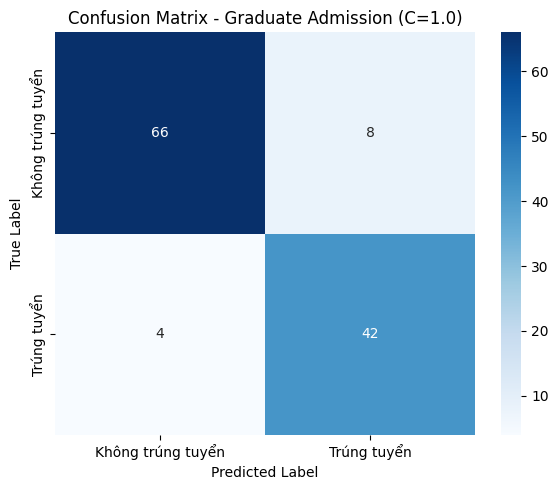

In [59]:
# Dự đoán trên tập kiểm tra
y_pred = clf.predict(X_test)

# Tính độ chính xác
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc * 100:.2f}%")

# Ma trận nhầm lẫn
cm = confusion_matrix(y_test, y_pred)

# Vẽ ma trận nhầm lẫn
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Không trúng tuyển', 'Trúng tuyển'],
            yticklabels=['Không trúng tuyển', 'Trúng tuyển'])
plt.title(f'Confusion Matrix - Graduate Admission (C={C})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()
